# Wafer Anomaly Detection — PatchCore + ViT-B/16 (WM-811K)

Backbone: **ViT-B/16** (pretrained on ImageNet-21k via `timm`)  
Hardware target: **RTX 4060 8 GB VRAM, 32 GB RAM**

## Why the previous version crashed (and how this one fixes it)

The crash came from `build_tensor()` — it pre-converted every wafer map to a
float32 tensor and stacked them all in RAM **before** any training started.

```
150k images × 224 × 224 × 3 channels × 4 bytes = ~30 GB   ← OOM on 32 GB machine
```

This notebook uses a **lazy `WaferDataset`** instead.  
Wafer maps stay as compact numpy arrays inside the DataFrame (~few KB each).  
The DataLoader converts **one batch at a time** only when needed.

| Approach | RAM for 150k images | Peak during run |
|---|---|---|
| Pre-built tensors (old) | ~30 GB | ~30 GB + model |
| Lazy `WaferDataset` (this) | ~2–4 GB (raw maps) | ~4–6 GB total |

## Pipeline
1. Load WM-811K, clean, split → DataFrames only (no tensors)
2. `WaferDataset` converts maps on-the-fly per batch
3. ViT-B/16 extracts patch token embeddings (block 6 of 12)
4. Build PatchCore memory bank from train-normal tokens
5. Tune threshold on tune-normal only (no defect leakage)
6. Final evaluation on held-out test split

In [1]:
# -- 0. Install dependencies if needed -----------------------------------------
import importlib, subprocess, sys
for pkg in ['timm', 'tqdm']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('timm + tqdm ready')

timm + tqdm ready


In [2]:
# -- 1. Imports ----------------------------------------------------------------
import os, gc, random, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

print('Device:', DEVICE)
if USE_CUDA:
    p = torch.cuda.get_device_properties(0)
    print(f'GPU: {p.name}  VRAM: {p.total_memory/1e9:.1f} GB')

C:\Users\kyler\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU  VRAM: 8.6 GB


In [3]:
# ── 2. Configuration ──────────────────────────────────────────────────────────
DATA_PATH  = '../data/raw/LSWMD.pkl'   # ← adjust to your path
IMAGE_SIZE = 224

# These are your reduced values — safe for 32 GB RAM with lazy loading
TRAIN_NORMAL_N = 60_000
TUNE_NORMAL_N  = 20_000
TEST_NORMAL_N  = 50_000
TEST_DEFECT_N  =  2_000

# ViT settings
# Block 6 of 12 is the sweet spot: mid-level structural + semantic features.
# Change to 3-5 for faster/lighter, 8-9 for more semantic richness.
VIT_FEATURE_BLOCK = 6
PATCH_EMBED_DIM   = 128    # project 768-d tokens → 128-d to save VRAM

# Memory bank
# 60k × 196 tokens = 11.7M patches; cap at 400k (200 MB VRAM)
MEMORY_BANK_MAX_PATCHES = 400_000

# Scoring
SCORE_CHUNK      = 512    # reduce to 256 if CUDA OOM during scoring
PATCHCORE_NN_K   = 3
TOPK_PATCH_RATIO = 0.1    # 196 tokens × 0.1 ≈ top-20 per image

# DataLoader
# NUM_WORKERS=4 uses multiprocessing — zero overhead for RAM since each
# worker only holds one batch of raw maps at a time.
# On Windows: set NUM_WORKERS=0 if you hit pickle errors.
BATCH_SIZE  = 128
NUM_WORKERS = 0

# Threshold sweep
THRESHOLD_PERCENTILE_MIN   = 90
THRESHOLD_PERCENTILE_MAX   = 99.9
THRESHOLD_PERCENTILE_STEPS = 100
THRESHOLD_GRID_STEPS       = 300

# Outputs
ARTIFACT_DIR        = '../artifacts/patchcore_vit_b16_811k'
MODEL_EXPORT_PATH   = os.path.join(ARTIFACT_DIR, 'patchcore_vit_b16_model.pt')
METRICS_EXPORT_PATH = os.path.join(ARTIFACT_DIR, 'evaluation_metrics.json')
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f'ViT block={VIT_FEATURE_BLOCK}  embed_dim={PATCH_EMBED_DIM}')
print(f'Bank cap={MEMORY_BANK_MAX_PATCHES:,}  batch={BATCH_SIZE}  workers={NUM_WORKERS}')
print(f'Artifacts → {ARTIFACT_DIR}')

ViT block=6  embed_dim=128
Bank cap=400,000  batch=128  workers=0
Artifacts → ../artifacts/patchcore_vit_b16_811k


In [4]:
# ── 3. Load & clean dataset ───────────────────────────────────────────────────
# Only DataFrames are created here — NO tensors, NO float32 copies.
# Raw wafer maps stay as object-dtype numpy arrays in the DataFrame.

df = pd.read_pickle(DATA_PATH)
print('Raw shape:', df.shape)

def parse_failure_label(v):
    if v is None: return 'unknown'
    if isinstance(v, float) and np.isnan(v): return 'unknown'
    if isinstance(v, (list, tuple, np.ndarray)):
        a = np.array(v).reshape(-1)
        return 'unknown' if len(a) == 0 else str(a[0])
    return str(v)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).str.strip()

invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

print(f'Labeled: {len(df):,}   Normal: {len(normal_df):,}   Defect: {len(defect_df):,}')
print('\nDefect breakdown:')
print(defect_df['failure_label'].value_counts())

Raw shape: (811457, 6)
Labeled: 172,950   Normal: 147,431   Defect: 25,519

Defect breakdown:
failure_label
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


In [5]:
# ── 4. Split ──────────────────────────────────────────────────────────────────
req_n = TRAIN_NORMAL_N + TUNE_NORMAL_N + TEST_NORMAL_N
req_d = TEST_DEFECT_N

if len(normal_df) < req_n:
    raise ValueError(f'Need {req_n:,} normals, have {len(normal_df):,}')
if len(defect_df) < req_d:
    raise ValueError(f'Need {req_d:,} defects, have {len(defect_df):,}')

rng = np.random.default_rng(SEED)
ns = normal_df.iloc[rng.permutation(len(normal_df))].reset_index(drop=True)
ds = defect_df.iloc[rng.permutation(len(defect_df))].reset_index(drop=True)

a = TRAIN_NORMAL_N
b = a + TUNE_NORMAL_N
c = b + TEST_NORMAL_N

train_normal_df = ns.iloc[0:a].copy()
tune_normal_df  = ns.iloc[a:b].copy()
test_normal_df  = ns.iloc[b:c].copy()
test_defect_df  = ds.iloc[0:TEST_DEFECT_N].copy()

# Free the large unsplit dataframes — keep only the slices
del df, normal_df, defect_df, ns, ds
gc.collect()

print(f'Train normal : {len(train_normal_df):>7,}')
print(f'Tune  normal : {len(tune_normal_df):>7,}')
print(f'Test  normal : {len(test_normal_df):>7,}')
print(f'Test  defect : {len(test_defect_df):>7,}')

Train normal :  60,000
Tune  normal :  20,000
Test  normal :  50,000
Test  defect :   2,000


In [6]:
# ── 5. Lazy WaferDataset ──────────────────────────────────────────────────────
#
# KEY RAM FIX: no tensor is created until __getitem__ is called for a single
# sample. The DataLoader batches these calls across NUM_WORKERS processes,
# so at most BATCH_SIZE tensors exist in memory at once.
#
# Raw map storage: 1 wafer map ≈ 26×26 int8 ≈ 700 bytes
# vs tensor:       1 wafer map ≈ 224×224×3 float32 ≈ 602 KB
# Ratio: ~860× more compact in the DataFrame.

class WaferDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, size: int = 224):
        self.maps   = frame['waferMap'].values   # numpy object array of 2-D arrays
        self.labels = frame['is_anomaly'].values.astype(np.int64)
        self.size   = size

    def __len__(self):
        return len(self.maps)

    def __getitem__(self, idx):
        arr = np.clip(np.array(self.maps[idx], dtype=np.int64), 0, 2)
        x   = torch.tensor(arr, dtype=torch.long)
        x   = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()  # [3, H, W]
        x   = F.interpolate(
                  x.unsqueeze(0),
                  size=(self.size, self.size),
                  mode='nearest'
              ).squeeze(0)                                            # [3, 224, 224]
        return x, int(self.labels[idx])


loader_kw = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_CUDA,
    persistent_workers=(NUM_WORKERS > 0),
)

train_loader       = DataLoader(WaferDataset(train_normal_df, IMAGE_SIZE), **loader_kw)
tune_normal_loader = DataLoader(WaferDataset(tune_normal_df,  IMAGE_SIZE), **loader_kw)
test_normal_loader = DataLoader(WaferDataset(test_normal_df,  IMAGE_SIZE), **loader_kw)
test_defect_loader = DataLoader(WaferDataset(test_defect_df,  IMAGE_SIZE), **loader_kw)

for name, ldr in [('train_normal', train_loader), ('tune_normal', tune_normal_loader),
                  ('test_normal', test_normal_loader), ('test_defect', test_defect_loader)]:
    print(f'{name:<14}: {len(ldr):>4} batches')

# Smoke-test one batch
xb, yb = next(iter(train_loader))
print(f'\nBatch shape: {tuple(xb.shape)}  dtype={xb.dtype}  sample labels={yb[:4].tolist()}')

train_normal  :  469 batches
tune_normal   :  157 batches
test_normal   :  391 batches
test_defect   :   16 batches

Batch shape: (128, 3, 224, 224)  dtype=torch.float32  sample labels=[0, 0, 0, 0]


In [7]:
# ── 6. ViT-B/16 feature extractor ────────────────────────────────────────────
# Forward hook on block[VIT_FEATURE_BLOCK] captures [B, 197, 768] token output.
# We drop the CLS token → [B, 196, 768] spatial patch tokens.
# Projected to [B, 196, PATCH_EMBED_DIM] for memory efficiency.

class ViTPatchExtractor(nn.Module):
    def __init__(self, block_idx: int = VIT_FEATURE_BLOCK,
                 proj_dim: int = PATCH_EMBED_DIM):
        super().__init__()
        self.vit = timm.create_model(
            'vit_base_patch16_224.augreg_in21k_ft_in1k',
            pretrained=True,
            num_classes=0,
        )
        self._feat = None
        self.vit.blocks[block_idx].register_forward_hook(
            lambda m, i, o: setattr(self, '_feat', o)
        )
        self.proj = nn.Linear(768, proj_dim, bias=False)

    def forward(self, x):
        self.vit(x)                    # hook fires mid-pass
        return self._feat[:, 1:, :]    # drop CLS → [B, 196, 768]


extractor = ViTPatchExtractor().to(DEVICE).eval()
for p in extractor.parameters():
    p.requires_grad = False

# Smoke-test
with torch.inference_mode():
    dummy = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    out   = extractor(dummy)
    proj  = extractor.proj(out)
print(f'ViT block-{VIT_FEATURE_BLOCK} output : {tuple(out.shape)}')   # [2, 196, 768]
print(f'After projection         : {tuple(proj.shape)}')              # [2, 196, 128]

ViT block-6 output : (2, 196, 768)
After projection         : (2, 196, 128)


In [8]:
# -- 7. Build PatchCore memory bank --------------------------------------------
# 60k images x 196 tokens = 11.7M patches -> subsample to MEMORY_BANK_MAX_PATCHES.
# Sampled tensors stay on GPU; no CPU round-trips.

def extract_embeddings(xb: torch.Tensor) -> torch.Tensor:
    """L2-normalised embeddings: [B*196, proj_dim] on GPU."""
    with torch.inference_mode():
        with torch.autocast('cuda', torch.float16, enabled=USE_CUDA):
            feat = extractor(xb)          # [B, 196, 768]
            emb  = extractor.proj(feat)   # [B, 196, proj_dim]
        emb = emb.float().reshape(-1, emb.shape[-1])
        emb = F.normalize(emb, p=2, dim=1)
    return emb


sampled, total_seen, sample_ratio = [], 0, None

print('Building memory bank...')
bank_iter = tqdm(
    enumerate(train_loader),
    total=len(train_loader),
    desc='Bank build',
    unit='batch',
)
for step, (xb, _) in bank_iter:
    xb  = xb.to(DEVICE)
    emb = extract_embeddings(xb)
    total_seen += len(emb)

    if sample_ratio is None:
        tokens_per_img  = len(emb) // len(xb)
        estimated_total = tokens_per_img * len(train_normal_df)
        sample_ratio    = min(1.0, MEMORY_BANK_MAX_PATCHES / estimated_total)
        print(f'  Tokens/image : {tokens_per_img}')
        print(f'  Est. total   : {estimated_total:,}')
        print(f'  Sample ratio : {sample_ratio:.5f}')

    if sample_ratio < 1.0:
        k   = max(1, int(round(len(emb) * sample_ratio)))
        idx = torch.randperm(len(emb), device=DEVICE)[:k]
        emb = emb[idx]

    sampled.append(emb)

    if (step + 1) % 20 == 0 or (step + 1) == len(train_loader):
        n = sum(len(e) for e in sampled)
        bank_iter.set_postfix(bank_tokens=f'{n:,}')

memory_bank = torch.cat(sampled, dim=0)
del sampled; gc.collect()

if len(memory_bank) > MEMORY_BANK_MAX_PATCHES:
    idx = torch.randperm(len(memory_bank), device=DEVICE)[:MEMORY_BANK_MAX_PATCHES]
    memory_bank = memory_bank[idx]

memory_bank   = F.normalize(memory_bank, p=2, dim=1).contiguous()
memory_bank_t = memory_bank.t().contiguous()

mb_mb = memory_bank.element_size() * memory_bank.numel() / 1e6
print(f'Final bank : {len(memory_bank):,} x {memory_bank.shape[1]}-d  ({mb_mb:.1f} MB VRAM)')

Building memory bank...


Bank build:   0%|          | 1/469 [00:00<04:57,  1.57batch/s]

  Tokens/image : 196
  Est. total   : 11,760,000
  Sample ratio : 0.03401


Bank build: 100%|██████████| 469/469 [01:59<00:00,  3.92batch/s, bank_tokens=399,844]

Final bank : 399,844 x 128-d  (204.7 MB VRAM)


In [9]:
# -- 8. PatchCore scoring -------------------------------------------------------

def min_dist_to_bank(patches, bank_t, chunk=512, k=3):
    out = []
    for i in range(0, len(patches), chunk):
        p    = patches[i:i+chunk]
        sim  = p @ bank_t
        kk   = min(k, sim.shape[1])
        best = sim.topk(kk, dim=1).values
        dist = torch.sqrt(torch.clamp(2.0 - 2.0 * best, min=0.0)).mean(dim=1)
        out.append(dist)
    return torch.cat(out)


def score_loader(loader, bank_t, topk_ratio=0.1, nn_k=3, desc='Scoring'):
    scores = []
    with torch.inference_mode():
        pbar = tqdm(loader, total=len(loader), desc=desc, unit='batch')
        for xb, _ in pbar:
            xb = xb.to(DEVICE)
            with torch.autocast('cuda', torch.float16, enabled=USE_CUDA):
                feat = extractor(xb)
                emb  = extractor.proj(feat)
            emb = emb.float().reshape(-1, emb.shape[-1])
            emb = F.normalize(emb, p=2, dim=1)

            ps   = min_dist_to_bank(emb, bank_t, SCORE_CHUNK, nn_k)
            b    = len(xb)
            ps   = ps.reshape(b, -1)
            topk = max(1, int(round(ps.shape[1] * topk_ratio)))
            topk = min(topk, ps.shape[1])
            s    = ps.topk(topk, dim=1).values.mean(dim=1)
            scores.append(s.cpu())
    return torch.cat(scores).numpy()


kw = dict(topk_ratio=TOPK_PATCH_RATIO, nn_k=PATCHCORE_NN_K)

train_scores       = score_loader(train_loader,       memory_bank_t, desc='Score train-normal', **kw)
tune_normal_scores = score_loader(tune_normal_loader, memory_bank_t, desc='Score tune-normal', **kw)
test_normal_scores = score_loader(test_normal_loader, memory_bank_t, desc='Score test-normal', **kw)
test_defect_scores = score_loader(test_defect_loader, memory_bank_t, desc='Score test-defect', **kw)

# Z-normalise using train-normal statistics
mu  = float(np.mean(train_scores))
std = float(np.std(train_scores) + 1e-8)
def znorm(x): return (x - mu) / std

train_scores_z       = znorm(train_scores)
tune_normal_scores_z = znorm(tune_normal_scores)
test_normal_scores_z = znorm(test_normal_scores)
test_defect_scores_z = znorm(test_defect_scores)

np.savez_compressed(
    os.path.join(ARTIFACT_DIR, 'scores.npz'),
    train_scores_z=train_scores_z,
    tune_normal_scores_z=tune_normal_scores_z,
    test_normal_scores_z=test_normal_scores_z,
    test_defect_scores_z=test_defect_scores_z,
    train_mu=np.array(mu), train_std=np.array(std),
)
print(f'\nScores saved. mu={mu:.6f}  sigma={std:.6f}')

Score test-defect: 100%|██████████| 16/16 [00:24<00:00,  1.50s/batch]


Scores saved. mu=0.466561  sigma=0.030840


Threshold selected from tune_normal 90% quantile
z-threshold = 1.2202  raw = 0.504193
Tune_normal range: [-3.680, 8.411]


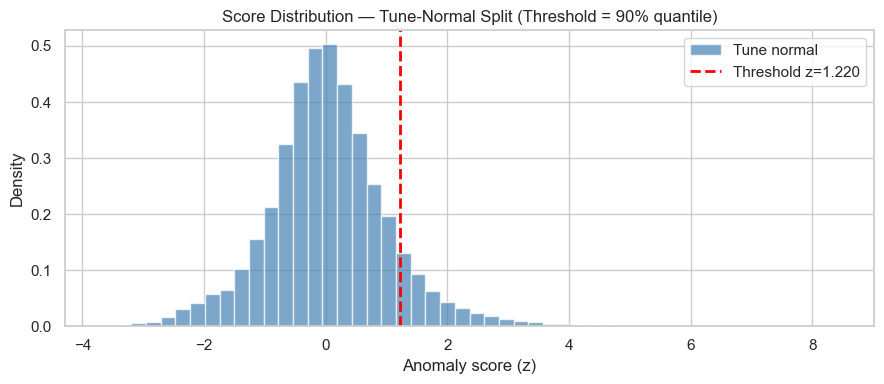

In [10]:
# -- 9. Threshold selection (tune-normal only, no leakage) ----------------------
# IMPORTANT: threshold is selected from tune_normal scores ONLY.
# No defect split is used during threshold selection.

with np.load(os.path.join(ARTIFACT_DIR, 'scores.npz')) as d:
    tune_normal_scores_z = d['tune_normal_scores_z']
    test_normal_scores_z = d['test_normal_scores_z']
    test_defect_scores_z = d['test_defect_scores_z']
    mu  = float(d['train_mu'])
    std = float(d['train_std'])

# Select threshold as quantile of tune_normal (no defect information used).
# Common choices: 90th (more sensitive to defects) → 95th (moderate) → 99th (strict).
THRESHOLD_QUANTILE = 0.90
threshold_z = float(np.quantile(tune_normal_scores_z, THRESHOLD_QUANTILE))
threshold_raw = mu + threshold_z * std

print(f'Threshold selected from tune_normal {THRESHOLD_QUANTILE:.0%} quantile')
print(f'z-threshold = {threshold_z:.4f}  raw = {threshold_raw:.6f}')
print(f'Tune_normal range: [{tune_normal_scores_z.min():.3f}, {tune_normal_scores_z.max():.3f}]')

# Score distribution visualization on tune-normal split.
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(tune_normal_scores_z, bins=50, alpha=0.7, label='Tune normal', color='steelblue', density=True)
ax.axvline(threshold_z, color='red', linewidth=2, linestyle='--', label=f'Threshold z={threshold_z:.3f}')
ax.set_xlabel('Anomaly score (z)')
ax.set_ylabel('Density')
ax.set_title(f'Score Distribution — Tune-Normal Split (Threshold = {THRESHOLD_QUANTILE:.0%} quantile)')
ax.legend()
plt.tight_layout()
plt.show()

ROC-AUC : 0.9535
Z-thr   : 1.2202   raw: 0.504193
              precision    recall  f1-score   support

      normal       0.99      0.90      0.94     50000
     anomaly       0.25      0.87      0.39      2000

    accuracy                           0.90     52000
   macro avg       0.62      0.88      0.67     52000
weighted avg       0.97      0.90      0.92     52000



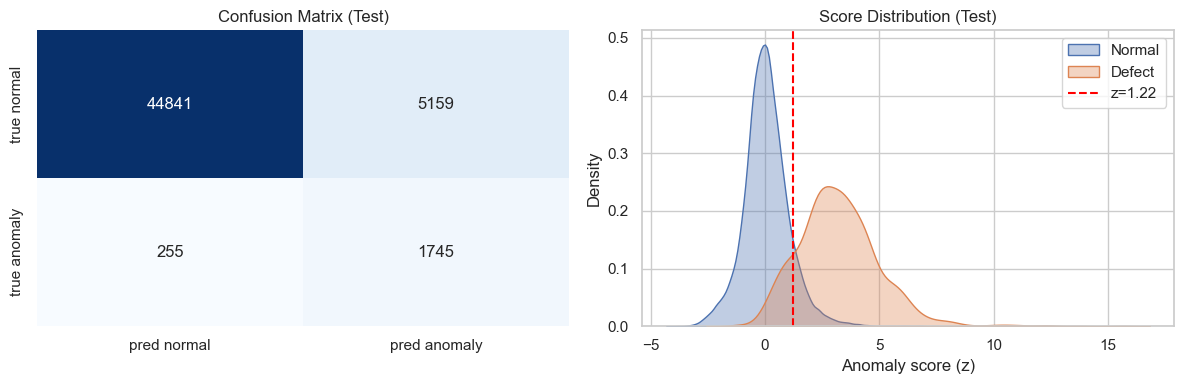


Per-class defect recall:


,count,detected,recall,mean_score
failure_label,,,,
Edge-Loc,386,287,0.744,2.745
Scratch,89,69,0.775,4.246
Loc,283,232,0.820,3.096
Center,332,276,0.831,2.828
Edge-Ring,788,759,0.963,3.220
Donut,37,37,1.000,5.518
Near-full,8,8,1.000,5.641
Random,77,77,1.000,4.991


In [11]:
# ── 10. Final test evaluation ─────────────────────────────────────────────────
# threshold_z = 1.5   # ← uncomment to override

y_true = np.concatenate([np.zeros(len(test_normal_scores_z), dtype=int),
                          np.ones( len(test_defect_scores_z), dtype=int)])
scores = np.concatenate([test_normal_scores_z, test_defect_scores_z])
y_pred = (scores > threshold_z).astype(int)

roc_auc = float(roc_auc_score(y_true, scores))
print(f'ROC-AUC : {roc_auc:.4f}')
print(f'Z-thr   : {threshold_z:.4f}   raw: {threshold_raw:.6f}')
print(classification_report(y_true, y_pred, target_names=['normal','anomaly']))

cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['pred normal','pred anomaly'],
            yticklabels=['true normal','true anomaly'])
axes[0].set_title('Confusion Matrix (Test)')

sns.kdeplot(test_normal_scores_z, label='Normal', fill=True, alpha=0.35, ax=axes[1])
sns.kdeplot(test_defect_scores_z, label='Defect', fill=True, alpha=0.35, ax=axes[1])
axes[1].axvline(threshold_z, color='red', ls='--', label=f'z={threshold_z:.2f}')
axes[1].set_xlabel('Anomaly score (z)'); axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution (Test)'); axes[1].legend()
plt.tight_layout(); plt.show()

# Per-class defect recall
tmp = test_defect_df.copy()
tmp['score']    = test_defect_scores_z
tmp['detected'] = (test_defect_scores_z > threshold_z).astype(int)
print('\nPer-class defect recall:')
display(
    tmp.groupby('failure_label')
       .agg(count=('detected','count'), detected=('detected','sum'),
            recall=('detected','mean'), mean_score=('score','mean'))
       .round(3).sort_values('recall')
)

Embed test-defect:  94%|█████████▍| 15/16 [00:04<00:00,  3.31batch/s]


UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, random_state=42, verbose=True)
Sat Mar 28 15:07:47 2026 Construct fuzzy simplicial set
Sat Mar 28 15:07:53 2026 Finding Nearest Neighbors
Sat Mar 28 15:07:58 2026 Finished Nearest Neighbor Search
Sat Mar 28 15:08:00 2026 Construct embedding


Epochs completed:   4%| ▎          18/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  16%| █▌         78/500 [00:01]

...

	completed  400  /  500 epochs


Epochs completed:  94%| █████████▎ 468/500 [00:03]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:04]


Sat Mar 28 15:08:04 2026 Finished embedding


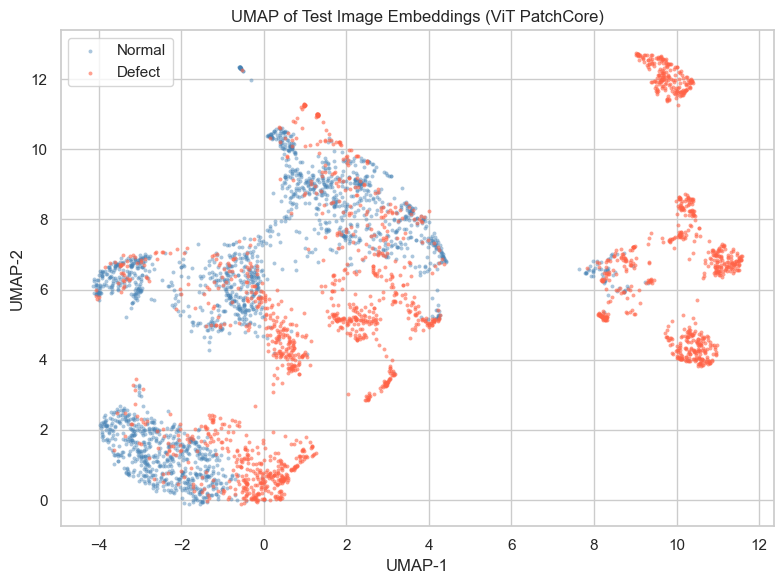

Saved UMAP figure: ../artifacts/patchcore_vit_b16_811k\umap_test_embeddings.png
Saved UMAP coords: ../artifacts/patchcore_vit_b16_811k\umap_test_embeddings.csv


In [12]:
# -- 11. UMAP diagnostic (test split) -------------------------------------------
# Visualize image-level embeddings (mean pooled patch embeddings).
# This is optional but useful to sanity-check separation quality.

import sys, subprocess
from sklearn.decomposition import PCA

# Rebuild loaders if cleanup already removed them.
if 'test_normal_loader' not in globals() or 'test_defect_loader' not in globals():
    print('Recreating test loaders for UMAP...')
    _loader_kw = dict(
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=USE_CUDA,
        persistent_workers=(NUM_WORKERS > 0),
    )
    test_normal_loader = DataLoader(WaferDataset(test_normal_df, IMAGE_SIZE), **_loader_kw)
    test_defect_loader = DataLoader(WaferDataset(test_defect_df, IMAGE_SIZE), **_loader_kw)

try:
    import umap.umap_ as umap
except Exception:
    print('Installing umap-learn...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'umap-learn', '-q'])
    import umap.umap_ as umap

MAX_UMAP_IMAGES_PER_SPLIT = 2000  # keep runtime reasonable

def collect_image_embeddings(loader, max_images=2000, desc='embed'):
    embs, labels = [], []
    seen = 0
    with torch.inference_mode():
        for xb, yb in tqdm(loader, total=len(loader), desc=desc, unit='batch'):
            xb = xb.to(DEVICE)
            with torch.autocast('cuda', torch.float16, enabled=USE_CUDA):
                feat = extractor(xb)
                emb  = extractor.proj(feat)  # [B, 196, D]
            img_emb = F.normalize(emb.float().mean(dim=1), p=2, dim=1)
            embs.append(img_emb.cpu().numpy())
            labels.append(yb.cpu().numpy())
            seen += len(yb)
            if seen >= max_images:
                break

    X = np.concatenate(embs, axis=0)[:max_images]
    y = np.concatenate(labels, axis=0)[:max_images]
    return X, y

print('Collecting test embeddings for UMAP...')
Xn, yn = collect_image_embeddings(
    test_normal_loader,
    max_images=MAX_UMAP_IMAGES_PER_SPLIT,
    desc='Embed test-normal',
)
Xd, yd = collect_image_embeddings(
    test_defect_loader,
    max_images=MAX_UMAP_IMAGES_PER_SPLIT,
    desc='Embed test-defect',
)

X = np.concatenate([Xn, Xd], axis=0)
y = np.concatenate([yn, yd], axis=0).astype(int)

# PCA pre-reduction speeds up UMAP and denoises high-dimensional embeddings.
n_pca = min(32, X.shape[1], X.shape[0] - 1)
Xp = PCA(n_components=n_pca, random_state=SEED).fit_transform(X)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=SEED,
    transform_seed=SEED,
    low_memory=True,
    verbose=True,
 )
coords = reducer.fit_transform(Xp)

fig, ax = plt.subplots(figsize=(8, 6))
m0 = (y == 0)
m1 = (y == 1)
ax.scatter(coords[m0, 0], coords[m0, 1], s=8, alpha=0.45, label='Normal', c='steelblue', linewidths=0)
ax.scatter(coords[m1, 0], coords[m1, 1], s=8, alpha=0.60, label='Defect', c='tomato', linewidths=0)
ax.set_title('UMAP of Test Image Embeddings (ViT PatchCore)')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.legend()
plt.tight_layout()
plt.show()

umap_png = os.path.join(ARTIFACT_DIR, 'umap_test_embeddings.png')
umap_csv = os.path.join(ARTIFACT_DIR, 'umap_test_embeddings.csv')
fig.savefig(umap_png, dpi=160, bbox_inches='tight')
pd.DataFrame({
    'umap_1': coords[:, 0],
    'umap_2': coords[:, 1],
    'label': y,
}).to_csv(umap_csv, index=False)
print(f'Saved UMAP figure: {umap_png}')
print(f'Saved UMAP coords: {umap_csv}')

In [13]:
# ── 11. Save artifact ─────────────────────────────────────────────────────────
artifact = {
    'extractor_state_dict': extractor.state_dict(),
    'threshold_z'  : float(threshold_z),
    'threshold_raw': float(threshold_raw),
    'train_score_mu' : float(mu),
    'train_score_std': float(std),
    'config': dict(
        backbone='vit_base_patch16_224.augreg_in21k_ft_in1k',
        vit_feature_block=VIT_FEATURE_BLOCK,
        patch_embed_dim=PATCH_EMBED_DIM,
        image_size=IMAGE_SIZE,
        train_normal_n=TRAIN_NORMAL_N,
        tune_normal_n=TUNE_NORMAL_N,
        test_normal_n=TEST_NORMAL_N,
        test_defect_n=TEST_DEFECT_N,
        memory_bank_max=MEMORY_BANK_MAX_PATCHES,
        score_chunk=SCORE_CHUNK,
        patchcore_nn_k=PATCHCORE_NN_K,
        topk_patch_ratio=TOPK_PATCH_RATIO,
    ),
}
torch.save(artifact, MODEL_EXPORT_PATH)

metrics = dict(
    roc_auc_z=roc_auc, threshold_z=float(threshold_z),
    threshold_raw=float(threshold_raw),
    train_score_mu=float(mu), train_score_std=float(std),
    confusion_matrix=cm.tolist(),
    n_test_normal=int(len(test_normal_scores_z)),
    n_test_defect=int(len(test_defect_scores_z)),
)
pd.Series(metrics).to_json(METRICS_EXPORT_PATH, indent=2)
print('Model  →', MODEL_EXPORT_PATH)
print('Metrics→', METRICS_EXPORT_PATH)

Model  → ../artifacts/patchcore_vit_b16_811k\patchcore_vit_b16_model.pt
Metrics→ ../artifacts/patchcore_vit_b16_811k\evaluation_metrics.json


In [14]:
# ── 12. Cleanup ───────────────────────────────────────────────────────────────
for name in [
    'memory_bank', 'memory_bank_t',
    'train_scores', 'tune_normal_scores',
    'test_normal_scores', 'test_defect_scores',
    'train_scores_z', 'tune_normal_scores_z',
    'test_normal_scores_z', 'test_defect_scores_z',
    'scores', 'y_true', 'y_pred',
    'train_loader', 'tune_normal_loader',
    'test_normal_loader', 'test_defect_loader',
]:
    if name in globals(): del globals()[name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache(); torch.cuda.ipc_collect()
print('Cleared.')

Cleared.


## Troubleshooting & tuning

| Symptom | Fix |
|---|---|
| `DefaultCPUAllocator: not enough memory` | Don't call `build_tensor()` or `torch.stack()` over the full dataset — the `WaferDataset` never does this |
| CUDA OOM during bank build / scoring | Reduce `BATCH_SIZE` 64→32 or `SCORE_CHUNK` 512→256 |
| `RuntimeError: pickle` with `NUM_WORKERS > 0` on Windows | Set `NUM_WORKERS = 0` |
| DataLoader slow (only 1 CPU core used) | Increase `NUM_WORKERS` to 4–8 |
| Want richer features | `VIT_FEATURE_BLOCK = 9` |
| Want faster run | `VIT_FEATURE_BLOCK = 3`, `BATCH_SIZE = 128` |

## RAM budget with lazy loading

```
Split DataFrames in RAM    ~2–4 GB   (raw wafer maps as numpy object arrays)
One batch of tensors       ~150 MB   (64 × 3 × 224 × 224 float32)
ViT-B/16 weights           ~330 MB VRAM (fp16 during inference)
Memory bank (200k × 128)   ~100 MB VRAM
Scoring buffers            ~500 MB VRAM
──────────────────────────────────────────────
Total RAM                  ~4–6 GB   (was ~30 GB — fixed)
Total VRAM                 ~3–5 GB   (well under 8 GB)
```